In [61]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os

In [62]:
WINDOWS = [30, 50, 70, 90, 100]

OUTPUT_LEN = 1
TOTAL_PREDICT_DAYS = 100
BATCH_SIZE = 32
LR = 0.0001
EPOCHS = 30


In [63]:
df = pd.read_csv("FPT_train.csv")
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

# Log transform
df["open_log"] = np.log(df["open"])
df["high_log"] = np.log(df["high"])
df["low_log"] = np.log(df["low"])
df["close_log"] = np.log(df["close"])

# Thêm features (cải tiến)
df["volatility"] = (df["high"] - df["low"]) / df["close"]
df["roc_1"] = df["close"].pct_change().fillna(0)
df["sma_5"] = df["close"].rolling(5).mean().fillna(method="bfill")
df["sma_5_log"] = np.log(df["sma_5"])

FEATURE_COLS = [
    "open_log", "high_log", "low_log", "close_log",
    "volatility", "roc_1", "sma_5_log"
]
TARGET_COL = "close_log"


/var/folders/rj/3qsy0vq12zj3_xz5g5n_k77w0000gn/T/ipykernel_70835/3504505865.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["sma_5"] = df["close"].rolling(5).mean().fillna(method="bfill")


In [64]:
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[FEATURE_COLS] = scaler.fit_transform(df[FEATURE_COLS])


In [65]:
class MultiDataset(Dataset):
    def __init__(self, df, input_len, output_len, feature_cols, target_col):
        self.data = df[feature_cols].values
        self.targets = df[target_col].values
        self.input_len = input_len
        self.output_len = output_len

    def __len__(self):
        return len(self.data) - self.input_len - self.output_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.input_len]
        y = self.targets[idx + self.input_len : idx + self.input_len + self.output_len]
        return torch.FloatTensor(x), torch.FloatTensor(y)


In [66]:
class DLinearMulti(nn.Module):
    def __init__(self, input_len, num_features, output_len):
        super().__init__()

        self.input_len = input_len
        self.output_len = output_len
        self.num_features = num_features

        self.linear_trend = nn.Linear(input_len * num_features, output_len)
        self.linear_seasonal = nn.Linear(input_len * num_features, output_len)

    def moving_avg(self, x, kernel=3):
        padding = kernel // 2
        x_pad = torch.nn.functional.pad(x, (0,0, padding, padding), mode='reflect')
        x_smooth = torch.nn.functional.avg_pool1d(
            x_pad.transpose(1,2), 
            kernel_size=kernel, 
            stride=1
        ).transpose(1,2)
        return x_smooth

    def forward(self, x):
        trend_part = self.moving_avg(x)
        seasonal_part = x - trend_part

        trend_flat = trend_part.reshape(x.size(0), -1)
        seasonal_flat = seasonal_part.reshape(x.size(0), -1)

        trend_out = self.linear_trend(trend_flat)
        seasonal_out = self.linear_seasonal(seasonal_flat)

        return trend_out + seasonal_out



In [67]:
if torch.cuda.is_available():
    device_name = "cuda"
elif torch.backends.mps.is_available():
    device_name = "mps"
else:
    device_name = "cpu"

device = torch.device(device_name)
print(f"Using device: {device}")


Using device: mps


In [68]:
def train_model_for_window(input_len, epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE):
    print(f"\nTraining model with window = {input_len}")
    dataset = MultiDataset(df_scaled, input_len, OUTPUT_LEN, FEATURE_COLS, TARGET_COL)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = DLinearMulti(input_len, len(FEATURE_COLS), OUTPUT_LEN).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            out = model(batch_x)                  # [B, 1]
            loss = criterion(out, batch_y)        # batch_y: [B, 1]
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(loader):.6f}")

    return model


In [69]:
# %%
models = {}
for w in WINDOWS:
    model_w = train_model_for_window(w, epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE)
    models[w] = model_w



Training model with window = 30
Epoch 5/30 - Loss: 0.049980
Epoch 10/30 - Loss: 0.030509
Epoch 15/30 - Loss: 0.018308
Epoch 20/30 - Loss: 0.010982
Epoch 25/30 - Loss: 0.006816
Epoch 30/30 - Loss: 0.004442

Training model with window = 50
Epoch 5/30 - Loss: 0.055365
Epoch 10/30 - Loss: 0.024522
Epoch 15/30 - Loss: 0.011398
Epoch 20/30 - Loss: 0.005728
Epoch 25/30 - Loss: 0.003257
Epoch 30/30 - Loss: 0.002157

Training model with window = 70
Epoch 5/30 - Loss: 0.109219
Epoch 10/30 - Loss: 0.050820
Epoch 15/30 - Loss: 0.024440
Epoch 20/30 - Loss: 0.012498
Epoch 25/30 - Loss: 0.006905
Epoch 30/30 - Loss: 0.004185

Training model with window = 90
Epoch 5/30 - Loss: 0.071428
Epoch 10/30 - Loss: 0.038765
Epoch 15/30 - Loss: 0.021204
Epoch 20/30 - Loss: 0.012578
Epoch 25/30 - Loss: 0.007853
Epoch 30/30 - Loss: 0.005213

Training model with window = 100
Epoch 5/30 - Loss: 0.086454
Epoch 10/30 - Loss: 0.042656
Epoch 15/30 - Loss: 0.022416
Epoch 20/30 - Loss: 0.012558
Epoch 25/30 - Loss: 0.00719

In [70]:
def get_windows_and_weights(day):
    """
    day: từ 1 đến TOTAL_PREDICT_DAYS
    Trả về window được dùng để ensemble cho ngày đó.
    Logic:
    1-30  : [30]
    31-50 : [30,50]
    51-70 : [50,70]
    71-90 : [70,90]
    91-100: [90,100]
    """
    if 1 <= day <= 30:
        return [30], [1]

    elif 31 <= day <= 50:
        return [30, 50], [3.5, 6.5]

    elif 51 <= day <= 70:
        return [50, 70], [3.5, 6.5]

    elif 71 <= day <= 90:
        return [70, 90], [3.5, 6.5]

    elif 91 <= day <= 100:
        return [90, 100], [3.5, 6.5]
    else:
        raise ValueError(f"Ngày {day} vượt range")


In [71]:
# %%
# Dùng toàn bộ lịch sử scaled để append dần các ngày tương lai
all_feats = df_scaled[FEATURE_COLS].values.copy()

pred_log_list = []

close_idx = FEATURE_COLS.index("close_log")

for day in range(1, TOTAL_PREDICT_DAYS + 1):

    win_list, weights = get_windows_and_weights(day)

    day_preds = []

    for w in win_list:
        model_w = models[w]
        model_w.eval()

        window_input = all_feats[-w:]

        inp = torch.FloatTensor(window_input).unsqueeze(0).to(device)

        with torch.no_grad():
            out = model_w(inp)[0].cpu().numpy()

        pred_log = float(out[0])
        day_preds.append(pred_log)

    # ensemble theo trọng số các windows trong win_list

    weights = np.array(weights, dtype=float)
    weights = weights / weights.sum()   # chuẩn hóa

    day_preds = np.array(day_preds)

    final_pred_log = float(np.sum(day_preds * weights))

    pred_log_list.append(final_pred_log)

    # cập nhật all_feats: giữ các feature khác, thay close_log bằng pred
    new_row = all_feats[-1].copy()
    new_row[close_idx] = final_pred_log
    all_feats = np.vstack([all_feats, new_row])


pred_close_log_scaled = np.array(pred_log_list)


In [72]:
pred_close_log = np.array(pred_log_list)

close_idx = FEATURE_COLS.index("close_log")
mean = scaler.mean_[close_idx]
std = np.sqrt(scaler.var_[close_idx])

pred_close_log_original = pred_close_log * std + mean
pred_price = np.exp(pred_close_log_original)


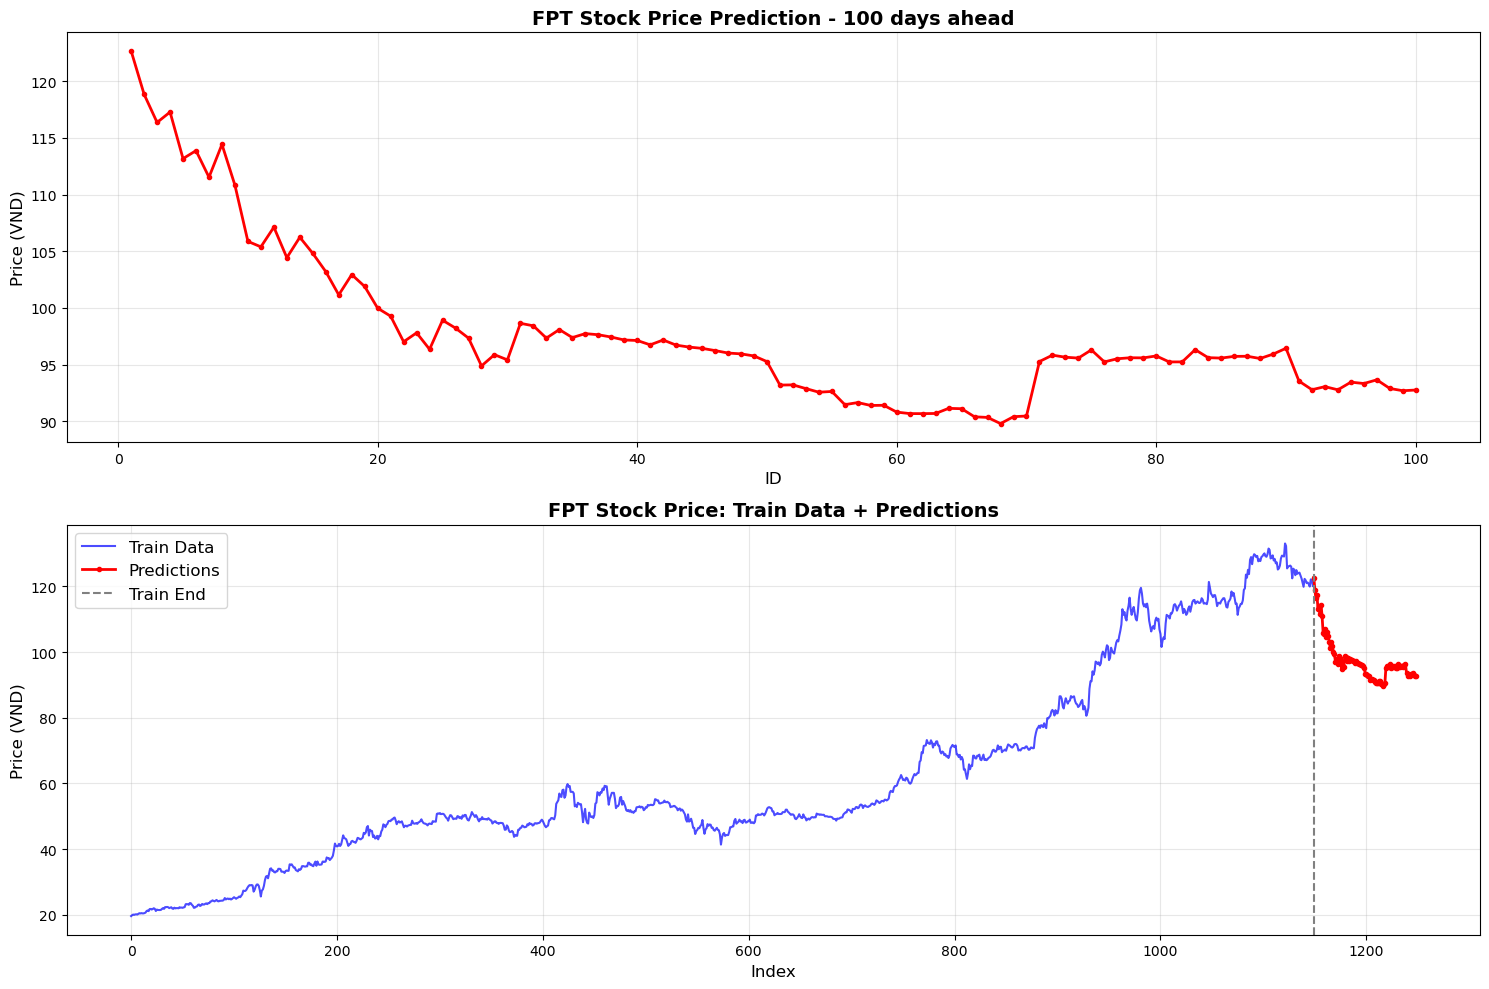

In [73]:
# ===== VISUALIZATION =====

prediction_ids = list(range(1, TOTAL_PREDICT_DAYS + 1))
predictions_close = pred_price  # rename cho giống baseline

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# ----- Plot 1: Dự đoán 100 ngày tiếp theo -----
axes[0].plot(
    prediction_ids,
    predictions_close,
    linewidth=2,
    color='red',
    marker='o',
    markersize=3
)
axes[0].set_title(
    f'FPT Stock Price Prediction - {TOTAL_PREDICT_DAYS} days ahead',
    fontsize=14,
    fontweight='bold'
)
axes[0].set_xlabel('ID', fontsize=12)
axes[0].set_ylabel('Price (VND)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# ----- Plot 2: Kết hợp train data và predictions -----
last_train_idx = len(df)

axes[1].plot(
    range(len(df)),
    df["close"],
    linewidth=1.5,
    color='blue',
    alpha=0.7,
    label='Train Data'
)

axes[1].plot(
    range(last_train_idx, last_train_idx + TOTAL_PREDICT_DAYS),
    predictions_close,
    linewidth=2,
    color='red',
    marker='o',
    markersize=3,
    label='Predictions'
)

axes[1].axvline(
    last_train_idx,
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label='Train End'
)

axes[1].set_title(
    'FPT Stock Price: Train Data + Predictions',
    fontsize=14,
    fontweight='bold'
)
axes[1].set_xlabel('Index', fontsize=12)
axes[1].set_ylabel('Price (VND)', fontsize=12)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [74]:
df_sub = pd.DataFrame({
    "id": np.arange(1, TOTAL_PREDICT_DAYS + 1),
    "close": pred_price
})

df_sub.to_csv("submission.csv", index=False)
print("Saved submission.csv!")


Saved submission.csv!


In [75]:
X_shifted = df_scaled[FEATURE_COLS].shift(1).dropna()

y_aligned = df_scaled[TARGET_COL].iloc[1:].values.reshape(-1, 1)
X_vals = X_shifted.values

X_bias = np.c_[np.ones((len(X_vals), 1)), X_vals]

beta = np.linalg.pinv(X_bias.T @ X_bias) @ (X_bias.T @ y_aligned)

print(f"Intercept: {beta[0][0]:.6f}\n")

for i, col in enumerate(FEATURE_COLS):
    print(f"{col:12s}: {beta[i+1][0]:.6f}")

Intercept: 0.003358

open_log    : -0.070432
high_log    : -1.132310
low_log     : 1.421991
close_log   : 0.656731
volatility  : 0.036114
roc_1       : 0.007900
sma_5_log   : 0.125385
